# Guess vs. AI Statistical Analysis

In this notebook, we will perform a thorough exploratory and statistical analysis on the Guess vs. AI game data. With the detailed per-game data now available, we can:

1. Compute basic statistics (means, medians, IQR, etc.) for human and AI question counts.
2. Check the distributions for normality and decide on appropriate statistical tests.
3. Conduct hypothesis tests (t-tests, Wilcoxon tests) to compare human vs. AI performance.
4. Explore category-level differences and whether certain categories are more challenging.
5. Analyze the performance of winners (AI or humans) specifically.
6. Add confidence intervals, effect sizes, and possibly look at proportions of wins and whether AI vs. human outcomes differ significantly.

While we now have more data than in the initial exploratory phase, the dataset may still be moderate in size. We should interpret results cautiously and consider gathering more data for robust statistical power. Still, these analyses will guide us in identifying trends and areas of interest for more in-depth future research.

In [2]:
import pandas as pd
import requests
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime


# Load the data from the provided API
response = requests.get("https://www.guess-vs-ai.com/api/detailed-statistics").json()

# timestamp now
print(datetime.now())

data = response["result"]
basic = data["basic"]
games = data["games"]

/Users/thomas/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2025-01-17 09:24:07.394196


## Basic Overview

Let's start by examining the basic aggregated statistics:
- Total Games
- Total AI Wins
- Total Human Wins
- Total Given Ups
- Started Games

These give a snapshot of the dataset scale and completion rates.

In [3]:
total_games = basic['totalGames']
total_ai_wins = basic['totalAIWins']
total_human_wins = basic['totalHumanWins']
total_given_up = basic['totalGivenUp']
total_started = basic['totalStarted']

print("Total Games:", total_games)
print("Total AI Wins:", total_ai_wins)
print("Total Human Wins:", total_human_wins)
print("Total Given Up:", total_given_up)
print("Total Started:", total_started)

min_questions_human = basic['minQuestionCountHuman']
max_questions_human = basic['maxQuestionCountHuman']
avg_questions_human = basic['avgQuestionCountHuman']
med_questions_human = basic['medQuestionCountHuman']

min_questions_ai = basic['minQuestionCountAI']
max_questions_ai = basic['maxQuestionCountAI']
avg_questions_ai = basic['avgQuestionCountAI']
med_questions_ai = basic['medQuestionCountAI']

print("\nHuman:")
print("Min Questions:", min_questions_human)
print("Max Questions:", max_questions_human)
print("Avg Questions:", avg_questions_human)
print("Median Questions:", med_questions_human)

print("\nAI:")
print("Min Questions:", min_questions_ai)
print("Max Questions:", max_questions_ai)
print("Avg Questions:", avg_questions_ai)
print("Median Questions:", med_questions_ai)

completed_games = total_ai_wins + total_human_wins
abandoned = total_started - total_games - total_given_up
successfully_operated_pct = (completed_games + total_given_up) / total_started * 100

print("\nCompleted Games:", completed_games)
print("Give-ups:", total_given_up)
print("Abandoned:", abandoned)
print("Successfully Operated:", successfully_operated_pct, "%")

Total Games: 75
Total AI Wins: 49
Total Human Wins: 26
Total Given Up: 37
Total Started: 205

Human:
Min Questions: 8
Max Questions: 56
Avg Questions: 18.846153846153847
Median Questions: 16

AI:
Min Questions: 4
Max Questions: 50
Avg Questions: 11.204081632653061
Median Questions: 9

Completed Games: 75
Give-ups: 37
Abandoned: 93
Successfully Operated: 54.63414634146342 %


**Interpretation:**
- The dataset shows how many games have completed, how many ended in AI vs. human wins, and how many players gave up.
- A certain percentage of started games might never finish (abandoned), indicating players might leave before conclusion.
- These basic metrics help frame our subsequent analyses.

## Visualizing Game Outcomes

To better understand the distribution of game outcomes, we can use pie charts to represent:

1. **Distribution of Completed Games by Winner:**
   - AI Wins
   - Human Wins

2. **Overall Distribution of Game Outcomes:**  
   - Completed Games (both AI and Human wins combined)
   - Given Up
   - Abandoned

These visual representations can quickly highlight which outcomes are most common and how dominant one party’s wins are.

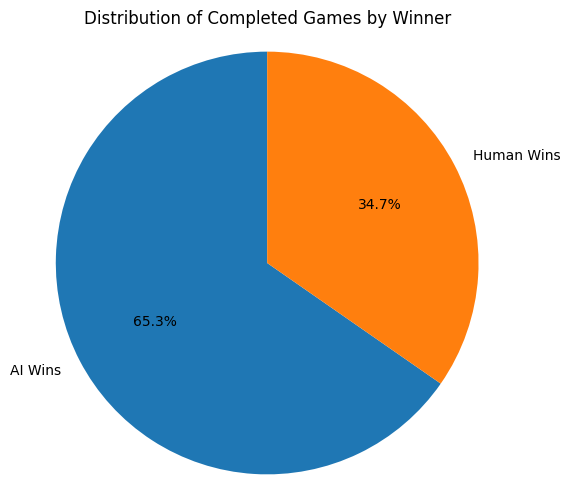

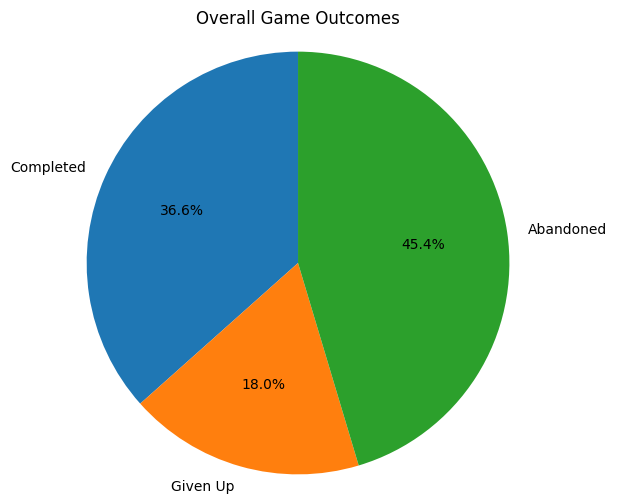

In [4]:
import matplotlib.pyplot as plt

# Data for wins among completed games
wins_labels = ['AI Wins', 'Human Wins']
wins_sizes = [total_ai_wins, total_human_wins]

# Pie chart for completed games distribution
plt.figure(figsize=(6,6))
plt.pie(wins_sizes, labels=wins_labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Completed Games by Winner')
plt.axis('equal')
plt.show()

# Data for outcome distribution
completed_games = total_ai_wins + total_human_wins
abandoned = total_started - total_games - total_given_up

outcome_labels = ['Completed', 'Given Up', 'Abandoned']
outcome_sizes = [completed_games, total_given_up, abandoned]

# Pie chart for overall outcomes
plt.figure(figsize=(6,6))
plt.pie(outcome_sizes, labels=outcome_labels, autopct='%1.1f%%', startangle=90)
plt.title('Overall Game Outcomes')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()



## Extracting Raw Distributions

We now extract the raw number of questions asked per game for both humans and AI. This allows us to:
- Compute measures of central tendency (mean, median).
- Compute dispersion (standard deviation, IQR).
- Perform normality tests and identify if parametric or non-parametric tests are appropriate.

In [5]:
human_counts = [g['counter']['human'] for g in games if g['counter']['human'] > 0]
ai_counts = [g['counter']['ai'] for g in games if g['counter']['ai'] > 0]

print("Human Question Counts (per game):", human_counts[:10], "...")  # Show only first 10 for brevity
print("AI Question Counts (per game):", ai_counts)

iqr_human = stats.iqr(human_counts)
iqr_ai = stats.iqr(ai_counts)

avg_human = np.mean(human_counts)
avg_ai = np.mean(ai_counts)

median_human = np.median(human_counts)
median_ai = np.median(ai_counts)

print("Length of human counts:", len(human_counts)) 
print("Length of ai counts:", len(ai_counts))
print("IQR (Human):", iqr_human)
print("IQR (AI):", iqr_ai)
print("Average (Human):", avg_human)
print("Average (AI):", avg_ai)
print("Median (Human):", median_human)
print("Median (AI):", median_ai)


q1_human = np.percentile(human_counts, 25)
q3_human = np.percentile(human_counts, 75)
iqr_human = q3_human - q1_human

q1_ai = np.percentile(ai_counts, 25)
q3_ai = np.percentile(ai_counts, 75)
iqr_ai = q3_ai - q1_ai

print("Q1 (Human):", q1_human)
print("Q3 (Human):", q3_human)
print("IQR (Human):", iqr_human)

print("Q1 (AI):", q1_ai)
print("Q3 (AI):", q3_ai)
print("IQR (AI):", iqr_ai)

Human Question Counts (per game): [2, 13, 3, 3, 1, 5, 9, 8, 4, 13] ...
AI Question Counts (per game): [5, 13, 5, 6, 4, 8, 10, 9, 7, 8, 11, 6, 11, 45, 11, 9, 9, 7, 5, 7, 6, 7, 14, 4, 7, 10, 10, 13, 11, 8, 16, 16, 5, 11, 6, 15, 6, 14, 23, 14, 9, 7, 11, 25, 11, 8, 4, 10, 2, 15, 22, 8, 14, 14, 18, 3, 6, 17, 14, 12, 2, 11, 18, 10, 23, 27, 6, 19, 8, 5, 9, 10, 4, 50, 13]
Length of human counts: 75
Length of ai counts: 75
IQR (Human): 11.0
IQR (AI): 7.5
Average (Human): 12.853333333333333
Average (AI): 11.426666666666666
Median (Human): 10.0
Median (AI): 10.0
Q1 (Human): 6.0
Q3 (Human): 17.0
IQR (Human): 11.0
Q1 (AI): 6.5
Q3 (AI): 14.0
IQR (AI): 7.5


## Extracting Raw Distributions (Winners Only)

In this section, we focus on extracting question counts **only from the winning party**. This means:
- If the AI won the game, we take the AI's question count.
- If the human won the game, we take

In [25]:
from scipy import stats

# Extract counts only for the winning side
winner_human_counts = [g['counter']['human'] for g in games if g['winner'] == 'human' and g['counter']['human'] > 0]
winner_ai_counts = [g['counter']['ai'] for g in games if g['winner'] == 'ai' and g['counter']['ai'] > 0]

print("Human Question Counts (Winners Only):", winner_human_counts[:10], "...")  # Show only first 10 for brevity
print("AI Question Counts (Winners Only):", winner_ai_counts[:10], "...")

# Compute IQR for each winner-only distribution
iqr_human_winners = stats.iqr(winner_human_counts) if len(winner_human_counts) > 1 else None
iqr_ai_winners = stats.iqr(winner_ai_counts) if len(winner_ai_counts) > 1 else None

# Compute 25th and 75th percentiles
q1_human_winners = np.percentile(winner_human_counts, 25) if len(winner_human_counts) > 1 else None
q3_human_winners = np.percentile(winner_human_counts, 75) if len(winner_human_counts) > 1 else None
q1_ai_winners = np.percentile(winner_ai_counts, 25) if len(winner_ai_counts) > 1 else None
q3_ai_winners = np.percentile(winner_ai_counts, 75) if len(winner_ai_counts) > 1 else None


avg_human_winners = np.mean(winner_human_counts) if len(winner_human_counts) > 1 else None
avg_ai_winners = np.mean(winner_ai_counts) if len(winner_ai_counts) > 1 else None

median_human_winners = np.median(winner_human_counts) if len(winner_human_counts) > 1 else None
median_ai_winners = np.median(winner_ai_counts) if len(winner_ai_counts) > 1 else None

print("IQR (Human Winners):", iqr_human_winners, "[", q1_human_winners, q3_human_winners, "]")
print("IQR (AI Winners):", iqr_ai_winners, "[", q1_ai_winners, q3_ai_winners, "]")

print("Average (Human Winners):", avg_human_winners)
print("Average (AI Winners):", avg_ai_winners)

print("Median (Human Winners):", median_human_winners)
print("Median (AI Winners):", median_ai_winners)

Human Question Counts (Winners Only): [13, 13, 18, 56, 13, 17, 15, 24, 12, 25] ...
AI Question Counts (Winners Only): [5, 5, 6, 4, 8, 10, 9, 7, 6, 11] ...
IQR (Human Winners): 7.75 [ 13.0 20.75 ]
IQR (AI Winners): 7.0 [ 6.0 13.0 ]
Average (Human Winners): 18.846153846153847
Average (AI Winners): 11.204081632653061
Median (Human Winners): 16.0
Median (AI Winners): 9.0


**Interpretation:**
- The IQR gives a sense of the spread of question counts for both humans and AI.
- A large IQR suggests more variability in how many questions are needed.

Next, we'll check normality to determine which statistical tests are suitable.

## Checking for Normality

We use Shapiro-Wilk tests to check if the distributions of question counts (human and AI) differ significantly from normality. If p < 0.05, we reject normality and consider non-parametric tests.

In [7]:
if len(human_counts) > 2 and len(ai_counts) > 2:
    shapiro_human = stats.shapiro(human_counts)
    shapiro_ai = stats.shapiro(ai_counts)
    print(f"Shapiro-Wilk Test (Human): statistic = {shapiro_human.statistic:.4f}, p-value = {shapiro_human.pvalue:.2e}")
    print(f"Shapiro-Wilk Test (AI): statistic = {shapiro_ai.statistic:.4f}, p-value = {shapiro_ai.pvalue:.2e}")
else:
    print("Not enough data points for a meaningful normality test.")

Shapiro-Wilk Test (Human): statistic = 0.7982, p-value = 9.37e-09
Shapiro-Wilk Test (AI): statistic = 0.7594, p-value = 9.44e-10


## Checking Normality for Winners Only

Now that we have extracted question counts specifically for the winning parties (both human and AI), we can check whether these distributions are normally distributed. By focusing only on games where a party won, we analyze a more uniform subset of the data, potentially gaining clearer insights into the nature of winning outcomes.

If these winner-only distributions are normal, we may consider using parametric tests (like a t-test) for hypothesis testing. If not, non-parametric tests (like Wilcoxon) would be more appropriate.

In [8]:
from scipy import stats

# Check normality for winner-only distributions
if len(winner_human_counts) > 2:
    shapiro_human_winners = stats.shapiro(winner_human_counts)
    print(f"Shapiro-Wilk Test (Human Winners): statistic={shapiro_human_winners.statistic:.4f}, p-value={shapiro_human_winners.pvalue:.10f}")
else:
    print("Not enough Human winner data for a normality test.")

if len(winner_ai_counts) > 2:
    shapiro_ai_winners = stats.shapiro(winner_ai_counts)
    print(f"Shapiro-Wilk Test (AI Winners): statistic={shapiro_ai_winners.statistic:.4f}, p-value={shapiro_ai_winners.pvalue:.10f}")
else:
    print("Not enough AI winner data for a normality test.")

Shapiro-Wilk Test (Human Winners): statistic=0.7458, p-value=0.0000240305
Shapiro-Wilk Test (AI Winners): statistic=0.7242, p-value=0.0000000290


**Interpretation:**
- If both distributions are not normal, we will prefer non-parametric tests (e.g., Wilcoxon signed-rank).
- If they appear normal, we might consider a paired t-test.
- The results here guide our choice of statistical methods.

## Hypothesis Testing: Comparing Human vs AI Question Counts

We can test if there's a significant difference in the number of questions asked by humans versus the AI. Since each game involves both a human and AI component, we can treat each game as a paired observation.

- If distributions are normal: use a paired t-test.
- If not normal: use a Wilcoxon signed-rank test.

In [9]:
if len(human_counts) > 2 and len(ai_counts) > 2:
    sh_h = stats.shapiro(human_counts)
    sh_a = stats.shapiro(ai_counts)
    # Decide test based on normality
        
    if sh_h.pvalue > 0.05 and sh_a.pvalue > 0.05:
        # Use paired t-test
        t_res = stats.ttest_rel(human_counts, ai_counts)
        print(f"Paired t-test result: statistic = {t_res.statistic:.4f}, p-value = {t_res.pvalue:.2e}")
    else:
        # Use Wilcoxon test
        w_res = stats.wilcoxon(human_counts, ai_counts)
        print(f"Wilcoxon test result: statistic = {w_res.statistic:.4f}, p-value = {w_res.pvalue:.10f}")
else:
    print("Not enough data for a meaningful hypothesis test.")

Wilcoxon test result: statistic = 840.0000, p-value = 0.0412835734


## Hypothesis Testing Between AI and Human Winners

While the sample sizes for AI and Human winners may differ significantly, we can still attempt a hypothesis test to compare their distributions. If the normality tests suggest non-normality, or sample sizes are too imbalanced, a non-parametric test like the Mann-Whitney U test can be used as a starting point.

**Important Considerations:**
- With unequal sample sizes, interpret results cautiously.
- If the human winner sample size is very small, the test may lack the power to detect differences.
- Clearly report limitations due to sample size differences and consider collecting more data if possible.

In [10]:
from scipy import stats

# Ensure you have winner_human_counts and winner_ai_counts defined as before

if len(winner_human_counts) > 2 and len(winner_ai_counts) > 2:
    # Example: Using the Mann-Whitney U test (non-parametric) due to potential non-normality and unequal sample sizes
    u_stat, p_value = stats.mannwhitneyu(winner_human_counts, winner_ai_counts, alternative='two-sided')
    print(f"Mann-Whitney U Test: U-statistic={u_stat}, p-value={p_value:.10f}")
else:
    print("Not enough data points for a meaningful hypothesis test.")

Mann-Whitney U Test: U-statistic=1034.0, p-value=0.0000097805


**Interpretation:**
- As data volume increases, these tests would let us determine if humans consistently ask more (or fewer) questions than the AI.
- If a test shows significance, we might conclude that one party tends to ask more questions. If not, we might say there's no significant difference.

## Confidence Intervals and Effect Size

To understand not just significance but also the magnitude of differences, we can compute:
- 95% Confidence Intervals for the mean difference.
- Cohen’s d as an effect size measure (if we assume approximate normality or still want an indication of effect magnitude).

Confidence intervals show the range of plausible values for the mean difference. Cohen’s d helps understand if the difference is small, moderate, or large.

In [11]:
if len(human_counts) > 2 and len(ai_counts) > 2:
    differences = np.array(human_counts) - np.array(ai_counts)
    mean_diff = np.mean(differences)
    se_diff = np.std(differences, ddof=1) / np.sqrt(len(differences))
    # 95% CI for mean difference
    ci = stats.t.interval(0.95, len(differences)-1, loc=mean_diff, scale=se_diff)
    
    # Cohen's d
    pooled_std = np.sqrt((np.std(human_counts, ddof=1)**2 + np.std(ai_counts, ddof=1)**2) / 2)
    cohen_d = mean_diff / pooled_std
    
    print(f"Mean difference (Human - AI): {mean_diff:.4f}")
    print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")
    print(f"Cohen's d: {cohen_d:.4f}")
else:
    print("Not enough data for CI or effect size calculation.")

Mean difference (Human - AI): 1.4267
95% CI: (0.2570, 2.5963)
Cohen's d: 0.1513


**Interpretation:**
- The confidence interval helps us understand the precision of our estimate of the difference in question counts.
- Cohen’s d gives a measure of how large this difference is in standard deviation units.
- Together, these give more nuance than a simple p-value.

## Proportions Testing (AI vs Human Wins)

We can test if the proportion of AI wins significantly differs from what we might expect by chance (e.g., a 50/50 split) using a Chi-square test or binomial test.

This helps determine if AI or humans have a statistically significant edge in winning rates.

In [13]:
# Observed counts: [AI Wins, Human Wins]
observed = np.array([total_ai_wins, total_human_wins])
expected = np.array([total_games/2, total_games/2])  # If we assume no difference expected

print("Observed counts:", observed)
print("Expected counts:", expected)

# Binomial test
binom_p = stats.binomtest(total_ai_wins, n=total_games, p=0.5)
print("Binomial test comparing AI wins to expected 50% win rate:")
print("p-value:", binom_p)

# Chi-square test
chi2, p, dof, expected_freq = stats.chi2_contingency([observed, expected])
print("Chi-square test comparing AI and Human wins distribution:")
print("Chi2:", chi2, "p-value:", p, "dof:", dof)
print("Expected frequencies:", expected_freq)


Observed counts: [49 26]
Expected counts: [37.5 37.5]
Binomial test comparing AI wins to expected 50% win rate:
p-value: BinomTestResult(k=49, n=75, alternative='two-sided', statistic=0.6533333333333333, pvalue=0.01058211705170527)
Chi-square test comparing AI and Human wins distribution:
Chi2: 3.010786946429384 p-value: 0.08271212633125773 dof: 1
Expected frequencies: [[43.25 31.75]
 [43.25 31.75]]


**Interpretation:**
- If p < 0.05, the distribution of wins (AI vs. Human) differs from what we'd expect under no-difference assumptions.
- This could indicate that one side has a statistically significant advantage.

## Visual Exploration

Let's create boxplots and histograms to visualize the distributions of question counts for AI and humans. We can also visualize category-level differences.

Visuals can provide insights into the shape, spread, and potential outliers in the data.

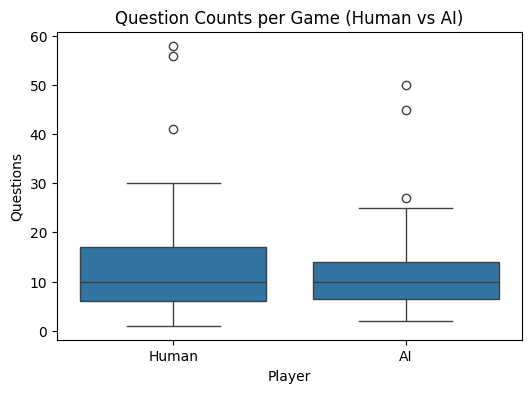

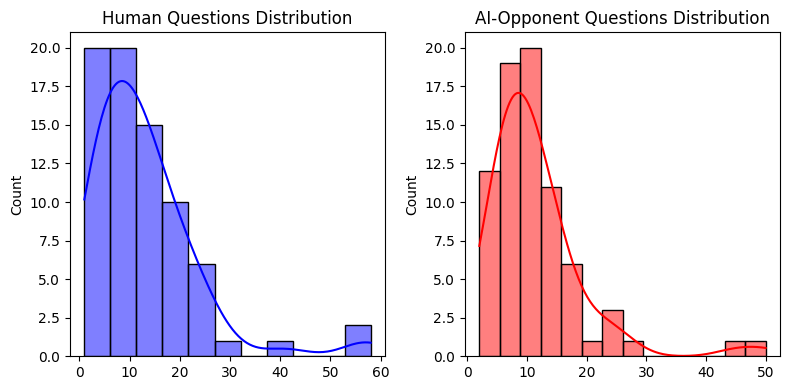

/var/folders/0t/1lvqwd6j3358cgc0kpg2k76w0000gn/T/ipykernel_13967/2541645550.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Player', y='Counts', data=data, palette={'Human': 'blue', 'AI-Opponent': 'red'})
/var/folders/0t/1lvqwd6j3358cgc0kpg2k76w0000gn/T/ipykernel_13967/2541645550.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Player', y='Counts', data=data, palette={'Human': 'blue', 'AI-Opponent': 'red'}, jitter=True)
/var/folders/0t/1lvqwd6j3358cgc0kpg2k76w0000gn/T/ipykernel_13967/2541645550.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

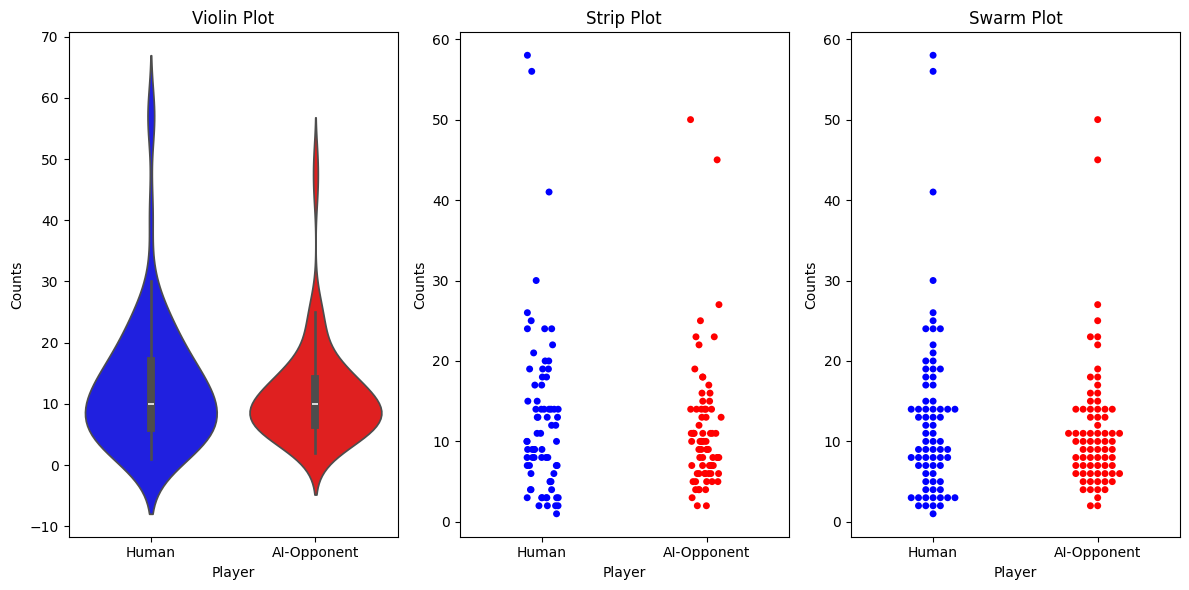

In [23]:
# Boxplot comparison
df_counts = pd.DataFrame({'Human': human_counts, 'AI': ai_counts})
df_melted = df_counts.melt(var_name='Player', value_name='Questions')

plt.figure(figsize=(6,4))
sns.boxplot(x='Player', y='Questions', data=df_melted)
plt.title('Question Counts per Game (Human vs AI)')
plt.show()

# Histograms
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.histplot(human_counts, kde=True, color='blue')
plt.title("Human Questions Distribution")

plt.subplot(1,2,2)
sns.histplot(ai_counts, kde=True, color='red')
plt.title("AI-Opponent Questions Distribution")

plt.tight_layout()
plt.show()

# Create a DataFrame
data = pd.DataFrame({
    'Counts': human_counts + ai_counts,
    'Player': ['Human'] * len(human_counts) + ['AI-Opponent'] * len(ai_counts)
})

plt.figure(figsize=(12,6))

# Violin plot
plt.subplot(1, 3, 1)
sns.violinplot(x='Player', y='Counts', data=data, palette={'Human': 'blue', 'AI-Opponent': 'red'})
plt.title("Violin Plot")

# Strip plot
plt.subplot(1, 3, 2)
sns.stripplot(x='Player', y='Counts', data=data, palette={'Human': 'blue', 'AI-Opponent': 'red'}, jitter=True)
plt.title("Strip Plot")

# Swarm plot
plt.subplot(1, 3, 3)
sns.swarmplot(x='Player', y='Counts', data=data, palette={'Human': 'blue', 'AI-Opponent': 'red'})
plt.title("Swarm Plot")

plt.tight_layout()
plt.show()





**Interpretation:**
- The boxplots and histograms help identify whether one distribution is shifted higher, more skewed, or more variable.
- KDE curves on histograms might show multiple peaks, skew, or approximate normality.

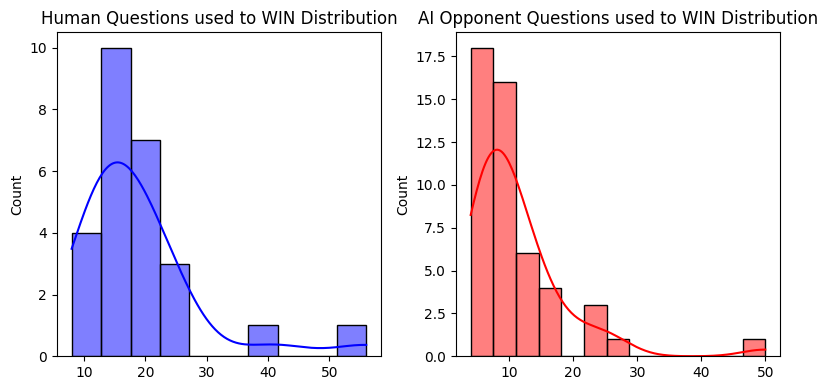

In [24]:
# Histograms
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.histplot(winner_human_counts, kde=True, color='blue')
plt.title("Human Questions used to WIN Distribution")

plt.subplot(1,2,2)
sns.histplot(winner_ai_counts, kde=True, color='red')
plt.title("AI Opponent Questions used to WIN Distribution")

plt.tight_layout()
plt.show()

## Category-Level Analysis

Now, let's examine performance across categories. This can show if certain categories are inherently more challenging for AI or humans, requiring more questions or resulting in different win rates.

We will:
1. Flatten `counter` to separate human and ai questions.
2. Group by `categoryName` and analyze mean, median, min, max question counts.
3. Focus on winner-only data and compute IQR.
4. Compare AI and human winners separately.

In [15]:
df_games = pd.DataFrame(games)
df_games['human_questions'] = df_games['counter'].apply(lambda x: x['human'])
df_games['ai_questions'] = df_games['counter'].apply(lambda x: x['ai'])

if 'categoryName' in df_games.columns:
    category_stats = df_games.groupby('categoryName').agg({
        'human_questions': ['mean', 'median', 'min', 'max'],
        'ai_questions': ['mean', 'median', 'min', 'max']
    })
    print(category_stats)
else:
    print("No category data available.")

                   human_questions                ai_questions               
                              mean median min max         mean median min max
categoryName                                                                 
Disney Animal            10.500000    9.0   5  19    11.833333   11.5   7  18
Harry Potter              8.666667    8.0   2  24     8.200000    7.0   5  22
Historical Figures       17.115385   14.5   4  56    15.038462   13.5   7  45
Marvel Universe          11.555556    5.0   1  58    11.555556    7.0   4  50
Star Wars                11.684211   10.0   3  26     8.842105    7.0   2  19


In [16]:
from scipy.stats import iqr

df_games['winner_questions'] = np.where(df_games['winner'] == 'ai', df_games['ai_questions'], df_games['human_questions'])

if 'categoryName' in df_games.columns:
    category_winner_stats = df_games.groupby('categoryName')['winner_questions'].agg(
        mean='mean',
        median='median',
        min='min',
        max='max',
        iqr=lambda x: iqr(x)
    )
    print("Winner-only category stats:")
    print(category_winner_stats)
else:
    print("No category data available.")

Winner-only category stats:
                         mean  median  min  max   iqr
categoryName                                         
Disney Animal       11.833333    11.5    7   18   2.5
Harry Potter         9.333333     8.0    5   22   7.0
Historical Figures  18.000000    14.0    7   56  11.5
Marvel Universe     12.333333     7.0    4   50   6.0
Star Wars           13.105263    13.0    6   26  10.5


In [17]:
if 'categoryName' in df_games.columns:
    category_winner_sep = df_games.groupby(['categoryName', 'winner'])['winner_questions'].agg(
        mean='mean',
        median='median',
        min='min',
        max='max',
        iqr=lambda x: iqr(x)
    ).reset_index()
    
    category_winner_pivot = category_winner_sep.pivot(index='categoryName', columns='winner')
    print("Category-level stats separated by winner:")
    print(category_winner_pivot)
else:
    print("No category data available.")

Category-level stats separated by winner:
                         mean            median       min       max        \
winner                     ai      human     ai human  ai human  ai human   
categoryName                                                                
Disney Animal       11.600000  13.000000   11.0  13.0   7    13  18    13   
Harry Potter         8.500000  12.666667    7.5  13.0   5    12  22    13   
Historical Figures  13.800000  23.727273   11.0  20.0   7    14  27    56   
Marvel Universe     11.625000  18.000000    6.5  18.0   4    18  50    18   
Star Wars            9.888889  16.000000    7.0  16.0   6     8  18    26   

                    iqr        
winner               ai human  
categoryName                   
Disney Animal       2.0   0.0  
Harry Potter        4.0   0.5  
Historical Figures  5.5  10.0  
Marvel Universe     4.5   0.0  
Star Wars           8.0   9.0  


**Interpretation:**
- By isolating winners, we see how many questions winners typically need in each category.
- Comparing AI vs. human winners by category can reveal:
  - Efficiency differences (lower median questions could mean more efficiency).
  - Consistency differences (lower IQR means more consistent performance).
- Categories where AI winners ask fewer questions might indicate the AI excels in that domain, and vice versa for humans.

# Conclusions and Future Work

With the current dataset, we've:
  - Analyzed overall and winner-only question counts.
  - Assessed normality and conducted appropriate hypothesis tests.
  - Examined differences between AI and human wins, including proportions tests.
  - Explored category-level differences to identify patterns of challenge and efficiency.

**Key Takeaways:**
- The results offer insights into whether AI or humans have the upper hand overall.
- Category-level analysis helps us identify domains where one party consistently outperforms the other.
- Confidence intervals and effect sizes add depth to our interpretation of differences.

**Next Steps:**
- Gather more data to increase statistical power and reduce uncertainty.
- Explore additional variables (timestamps, complexity of questions) if available.
- Consider advanced models (e.g., logistic regression) to predict winners based on question counts or categories.
- Integrate textual analysis on the Q&A messages to understand strategies and question complexity.

By continuously updating the dataset and refining these analyses, we can deepen our understanding of AI vs. human performance in these guessing games.

# User Experiance Feedback

## User Feedback Analysis

We have user feedback gathered via a form that allows users to rate their overall experience and provide qualitative feedback. The form includes multiple fields:

- **overallRating (1-5 stars)**: A numeric rating of the overall experience.
- **aiDifficulty**: Perceived AI difficulty, ranging from "Too hard" to "Too easy" with intermediate levels.
- **aiFairness**: Perceived fairness of the AI, from "Very unfair" to "Very fair".
- **gameLength**: Perception of whether the game length was "Very short" to "Very long".
- **overallEnjoyment**: How fun the experience was, from "Not fun at all" to "Very fun".
- **additionalComments**: Optional free-text field for extra feedback.

Even if some fields are not frequently used or have limited variability in responses, we will include them in our analysis. As more feedback is collected, these distributions and insights will become more meaningful.

In [18]:
import pandas as pd
import requests

feedback_url = "https://www.guess-vs-ai.com/api/feedback"
feedback_response = requests.get(feedback_url).json()
feedback_data = feedback_response.get("result", [])

df_feedback = pd.DataFrame(feedback_data)

print("Columns in feedback data:", df_feedback.columns)
df_feedback.head()

Columns in feedback data: Index(['id', 'userId', 'overallRating', 'aiDifficulty', 'aiFairness',
       'gameLength', 'overallEnjoyment', 'additionalComments', '_rid', '_self',
       '_etag', '_attachments', '_ts'],
      dtype='object')


,id,userId,overallRating,aiDifficulty,aiFairness,gameLength,overallEnjoyment,additionalComments,_rid,_self,_etag,_attachments,_ts
0,e4bab7ed-f336-4f3e-b9a9-02463b08524a,f0ca9da9-8f55-42da-b04f-a337715d7e15,4,Easy,Unfair,Long,Fun,"I had the collector, but collector wasn't enou...",+PstAI9q8fYHAAAAAAAAAA==,dbs/+PstAA==/colls/+PstAI9q8fY=/docs/+PstAI9q8...,"""1400a961-0000-4700-0000-67586c9d0000""",attachments/,1733848221
1,d9dcfd91-8b66-46e8-ae8c-771173fea580,e1e33e83-f0f1-4424-8a31-b2e49f897f6a,3,Hard,Very unfair,Just right,Okay,,+PstAI9q8fYIAAAAAAAAAA==,dbs/+PstAA==/colls/+PstAI9q8fY=/docs/+PstAI9q8...,"""1500f307-0000-4700-0000-675871e70000""",attachments/,1733849575
2,4bc485da-bf71-4f15-a2a8-b5b517b8477e,6a4a924e-3483-4eaa-aa11-cf063036ebc6,4,Just the right level of challenge,Very fair,Just right,Fun,"I won, but the AI showed me a text in which it...",+PstAI9q8fYJAAAAAAAAAA==,dbs/+PstAA==/colls/+PstAI9q8fY=/docs/+PstAI9q8...,"""4f00ac3f-0000-4700-0000-675c10fe0000""",attachments/,1734086910
3,6bbe8685-258c-493b-9fde-8112bf5426c3,087b9343-5e84-4a89-a6a8-dba23ddd8b2c,1,Easy,Sometimes,Very long,Not fun,"The historical figure was unknown to me, the g...",+PstAI9q8fYKAAAAAAAAAA==,dbs/+PstAA==/colls/+PstAI9q8fY=/docs/+PstAI9q8...,"""9f00fa10-0000-4700-0000-67616daf0000""",attachments/,1734438319
4,d9cea437-aff1-4a06-b7de-7909fc0be7a3,efabc1ac-1b88-4e16-8984-18ff9ec4f6d6,3,Hard,Unfair,Long,Okay,He guessed correctly but kept asking questions...,+PstAI9q8fYLAAAAAAAAAA==,dbs/+PstAA==/colls/+PstAI9q8fY=/docs/+PstAI9q8...,"""a000f6ed-0000-4700-0000-6761830c0000""",attachments/,1734443788


## Basic Overview of Feedback

Let's start with basic distributions and descriptive statistics for all the feedback fields. This gives us a snapshot of user sentiment and perceptions.

In [19]:
# Check how many responses we have
print(f"Number of feedback entries: {len(df_feedback)}\n")

# For categorical fields, show value counts
categorical_fields = ['aiDifficulty', 'aiFairness', 'gameLength', 'overallEnjoyment']
for field in categorical_fields:
    print(f"{field} Distribution:")
    print(df_feedback[field].value_counts(dropna=False))
    print()

# For numeric ratings:
print("Overall Rating Distribution:")
print(df_feedback['overallRating'].value_counts(dropna=False))
print("\nSummary Statistics for Overall Rating:")
print(df_feedback['overallRating'].describe())

Number of feedback entries: 24

aiDifficulty Distribution:
aiDifficulty
Just the right level of challenge    7
Easy                                 6
Hard                                 6
Very hard                            4
Too easy                             1
Name: count, dtype: int64

aiFairness Distribution:
aiFairness
Very fair      13
Sometimes       5
Unfair          4
Very unfair     1
Fair            1
Name: count, dtype: int64

gameLength Distribution:
gameLength
Just right    15
Long           3
Very long      3
Short          3
Name: count, dtype: int64

overallEnjoyment Distribution:
overallEnjoyment
Very fun          9
Fun               6
Okay              6
Not fun           2
Not fun at all    1
Name: count, dtype: int64

Overall Rating Distribution:
overallRating
5    10
4     7
3     4
1     2
2     1
Name: count, dtype: int64

Summary Statistics for Overall Rating:
count    24.000000
mean      3.916667
std       1.248187
min       1.000000
25%       3.000000
50%

**Interpretation:**

- **Overall Rating**: Shows how users rate their experience numerically. Means, medians, and ranges provide a quick quality gauge.
- **AI Difficulty, Fairness, Game Length, Overall Enjoyment**: These categorical fields map user perceptions to specific sentiments. Even if some categories aren't represented yet, we know the full range is available.
- **Missing or Unused Categories**: If some categories are never chosen, they will not appear in value counts or will have zero counts. As more data comes in, these distributions will likely fill out.

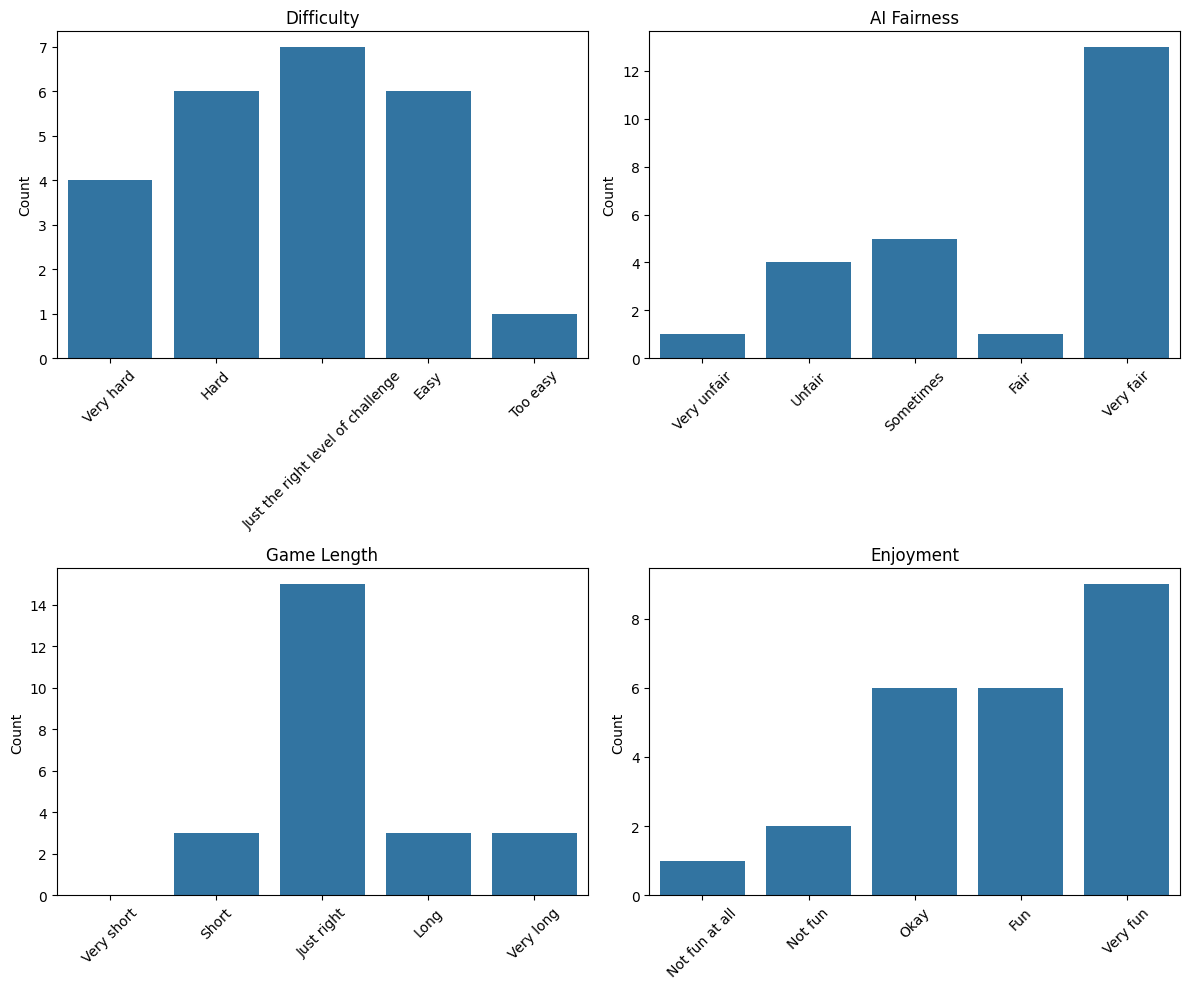

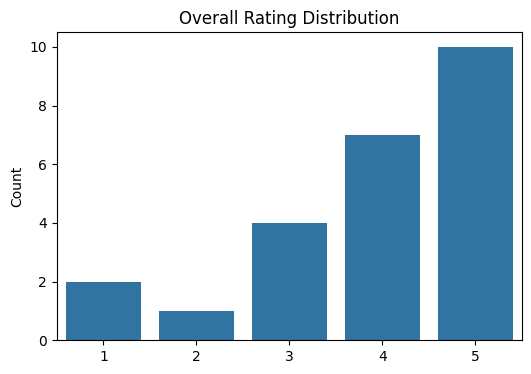

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the desired display orders for each categorical field
# Define display labels for fields
field_labels = {
    'aiDifficulty': 'Difficulty',
    'aiFairness': 'AI Fairness',
    'gameLength': 'Game Length',
    'overallEnjoyment': 'Enjoyment'
}


value_orders = {
    'aiDifficulty': [
        "Very hard",
        "Hard",
        "Just the right level of challenge",
        "Easy",
        "Too easy"
    ],
    'aiFairness': [
        "Very unfair",
        "Unfair",
        "Sometimes",
        "Fair",
        "Very fair"
    ],
    'gameLength': [
        "Very short",
        "Short",
        "Just right",
        "Long",
        "Very long"
    ],
    'overallEnjoyment': [
        "Not fun at all",
        "Not fun",
        "Okay",
        "Fun",
        "Very fun"
    ]
}

# Plot distributions for categorical fields in vertical orientation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, field in enumerate(categorical_fields):
    
    sns.countplot(
        x=field,
        data=df_feedback,
        ax=axes[i],
        order=value_orders[field]
    )

    axes[i].set_title(f"{field_labels[field]}")
    axes[i].set_xlabel("")  # Remove x-label since title is sufficient
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot distribution for overallRating with a defined order of [1,2,3,4,5]
plt.figure(figsize=(6,4))
sns.countplot(
    x='overallRating',
    data=df_feedback,
    order=[1, 2, 3, 4, 5]
)
plt.title("Overall Rating Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

**Insights:**
- The count plots provide a visual snapshot of the distribution of feedback categories.
- With more data, we might observe shifts in perceived difficulty, fairness, and enjoyment over time.
- If the game is often perceived as too long or unfair, developers might focus on adjustments to improve these aspects.

Next, we'll briefly examine the free-text comments for qualitative insights.

In [21]:
comments = df_feedback['additionalComments'].dropna().tolist()

print("Additional Comments:")
for i, comment in enumerate(comments, start=1):
    if comment.strip():
        print(f"{i}. {comment}")

Additional Comments:
1. I had the collector, but collector wasn't enough, had to Google his real name. Also, the AI started guessing non avenger characters after I told him it's an avenger
3. I won, but the AI showed me a text in which it stated that, in fact, the AI did win. "the AI reigned victorious", which is not true :-D
4. The historical figure was unknown to me, the game was also slow in responding 
5. He guessed correctly but kept asking questions. Also answer my easy questions like am I a student with I don't know
7. thank you it was very cool.
12. cursor should automatically be in the   prompt area
13. I wish the creators a lot of luck with this game
16. I find it unacceptable that the first thing I have to do is give away the name of the animal I have in mind. I have no way of knowing whether the ai has no access to this. I also do not see the need for this. It would be much more impressive if the ai guesses my animal without me having typed it in the beginning 
17. If possi

**Interpretation of Comments:**
- Free-form comments can highlight issues not captured by structured fields.
- Even with a small sample, we see mentions of:
  - Confusion about character identification ("the collector wasn't enough")
  - AI behavior (continuing to guess or guess incorrectly even after constraints)
  - Game responsiveness and speed

These comments suggest areas for improvement, such as clarifying instructions, ensuring AI respects user feedback or category constraints, and optimizing response times.

As more feedback accumulates, you can:
- Perform sentiment analysis to quantify user feelings.
- Identify common keywords or themes to address specific pain points.

## Next Steps for Feedback Analysis

- **Larger Sample**: As more feedback comes in, re-run these analyses to see if opinions shift.
- **Correlations with Game Data**: Correlate feedback (ratings, difficulty, fairness) with actual game outcomes (e.g., do longer games correlate with lower enjoyment?).
- **Sentiment Analysis**: Analyze free-text comments using NLP techniques to identify common themes or sentiment trends.
- **Time-Based Trends**: If timestamps are available, track how perceptions change over time or after updates.

This feedback loop helps guide incremental improvements to the game and user experience.